# 🌲🌲 Random Forest
---


## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Confusion Matrix & Classification Report
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 RandomizedSearchCV
   - 9.2 Best Parameters & Retrain
10. [Feature Importance Analysis](#10.-Feature-Importance-Analysis)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)


## 1. Introduction & Definition

**Random Forest** is a powerful, versatile, and robust ensemble learning algorithm that builds upon the concept of the Decision Tree. While a single Decision Tree is prone to overfitting and sensitive to the specific training data it sees, Random Forest overcomes these weaknesses through the principle of **wisdom of the crowd** — combining hundreds of diverse, independently trained trees to produce a collective prediction that is dramatically more stable and accurate than any single tree.

### Ensemble Learning
Ensemble learning leverages the idea that combining many "weak learners" can create a single "strong learner." In the case of Random Forest, the base learners are decision trees. Even if individual trees are prone to variance and error, provided they are better than random guessing and diverse from one another, their combined decision significantly mitigates their individual shortcomings.

### Bagging (Bootstrap Aggregating)
The algorithm draws $N$ samples from the training dataset **with replacement**. This implies some data points may be sampled multiple times, while others may not be sampled at all. Each individual tree is trained on its own bootstrap sample, ensuring that trees do not see the exact same data.

### Two Sources of Randomness
To maximize diversity among trees, Random Forest incorporates two key elements of randomness:
1. **Bootstrap sampling** (data randomness)
2. **Random feature subspace** (feature randomness): At each split in a tree, instead of considering all $p$ features to find the optimal split, it randomly selects a subset $m$ of features.
   - For **classification**, typically $m = \sqrt{p}$
   - For **regression**, typically $m = \\frac{p}{3}$

### The Final Prediction
Once all trees are constructed, the final output is determined by an aggregation process. For classification tasks, Random Forest uses **majority vote** (hard voting) across all individual tree predictions. 
$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \dots, h_T(x)\}$$

### Out-Of-Bag (OOB) Error
Because of bootstrapping, approximately $36.8\%$ of the training instances are left out of any given tree's training sample. These "out-of-bag" samples can be used as a free validation set. The OOB error rate provides a highly reliable estimate of the test error without needing a separate validation split.

### Law of Large Numbers
From probability theory, as the number of estimators (trees) $T$ approaches infinity, the variance of the ensemble's error approaches zero. While adding more trees increases computational cost, it does not lead to overfitting. The Random Forest stabilizes as it grows larger.


## 2. How It Works — Math & Intuition

Think of Random Forest as a panel of doctors evaluating a patient. Each doctor has been trained using a slightly different selection of medical literature (bootstrap sampling), and when diagnosing the patient, each doctor only examines a random subset of symptoms (random feature subspace). When they all make their diagnosis, the final decision is whatever condition the majority of doctors agree upon. 

### Step-by-Step Mechanism

1. **Bootstrap Sampling**: For each tree $i = 1, \dots, T$, draw a bootstrap sample of size $N$ with replacement from the training data.
2. **Node Splitting via Feature Subspace**: At each node of the tree, randomly select $m$ features from the total $p$ features. Find the single best split among those $m$ features to separate the classes (using Gini Impurity or Entropy).
3. **Full Tree Growth**: Grow the tree to its maximum depth. Do not prune it. Because the ensemble inherently averages out variance, we want individual trees to have high variance and low bias.
4. **Repeat**: Repeat this process until all $T$ trees are built.
5. **Prediction**: Aggregate predictions. For classification, the predicted class is the mode of predictions from individual trees:
   $$\hat{y} = \text{mode}\{h_1(x), h_2(x), \dots, h_T(x)\}$$

### Why Randomness Reduces Variance

If we simply trained $T$ identical trees on the same data, their predictions would be perfectly correlated, and averaging them wouldn't reduce variance at all. By forcing each tree to look at different data subsets and different feature subsets, Random Forest **decorrelates** the trees. 

The variance of the average of $T$ independent variables with variance $\sigma^2$ is $\\frac{\sigma^2}{T}$. For correlated variables with correlation $
ho$, the variance of the average becomes:
$$
\rho\sigma^2 + \\frac{1-
ho}{T}\sigma^2$$
Random feature selection significantly drives down the correlation $
ho$ between trees, allowing the second term to vanish as $T$ grows, shrinking the overall variance.

### Bias-Variance Tradeoff in Random Forest
A single deep decision tree has **low bias** but **high variance** (overfits easily). By bagging many deep trees, Random Forest preserves the **low bias** while dramatically reducing the **variance** through the ensemble average.


## 3. When To Use

- **Robust baseline needed**: It requires minimal tuning to achieve very strong performance.
- **Large datasets with high-dimensional features**: Handles large volumes of predictors effectively.
- **Feature importance required**: Provides a built-in mechanism for assessing feature influence.
- **Handling missing data**: Can handle missing values efficiently using surrogate splits or proximity.
- **When interpretability is less critical than accuracy**: A "black box" model compared to a single tree.


## 4. Pros & Cons

| Pros | Cons |
| :--- | :--- |
| **Highly Accurate & Robust:** Combines many trees to reduce overfitting drastically compared to single trees. | **Loss of Interpretability:** A "black box" model compared to a single, interpretable decision tree. |
| **Handles Non-Linearity:** Naturally models complex interactions and non-linear boundaries without transformations. | **Computationally Expensive:** Training hundreds of deep trees and predicting with them requires more CPU and memory. |
| **Requires Little Tuning:** The default hyperparameters usually yield excellent performance out-of-the-box. | **Memory Intensive:** Storing the topology of thousands of trees can consume a significant amount of RAM. |
| **Feature Importance:** Provides native ways to rank the predictive power of different features. | **Prediction Latency:** Evaluating a single instance requires traversing all $T$ trees, which is slower than e.g. Logistic Regression. |
| **Resistant to Outliers:** Bagging and tree splits are inherently robust against outliers in the input space. | **Struggles with Sparse Data:** Not the best choice for highly sparse representations (like TF-IDF text data). |


## 5. Dataset Upload & Exploration

We use sklearn's **Wine dataset** (3-class: wine cultivar classification with 13 chemical attributes)


In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Core data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Dataset and modeling tools
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics & Inspection
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# Warning suppression
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET
# ============================================================

wine_data = load_wine()

df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df['target'] = wine_data.target

print(f"Shape: {df.shape}\n")
df.info()

display(df.iloc[:, :5].describe().T)
display(df.head())

print("\nClass Distribution:")
print(df['target'].value_counts())


Shape: (178, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


### 💡 TIP for EDA
Random Forest can handle correlated features better than Logistic Regression, but extremely high multicollinearity can make feature importance unreliable (MDI will split importance between correlated features). Identify feature clusters.


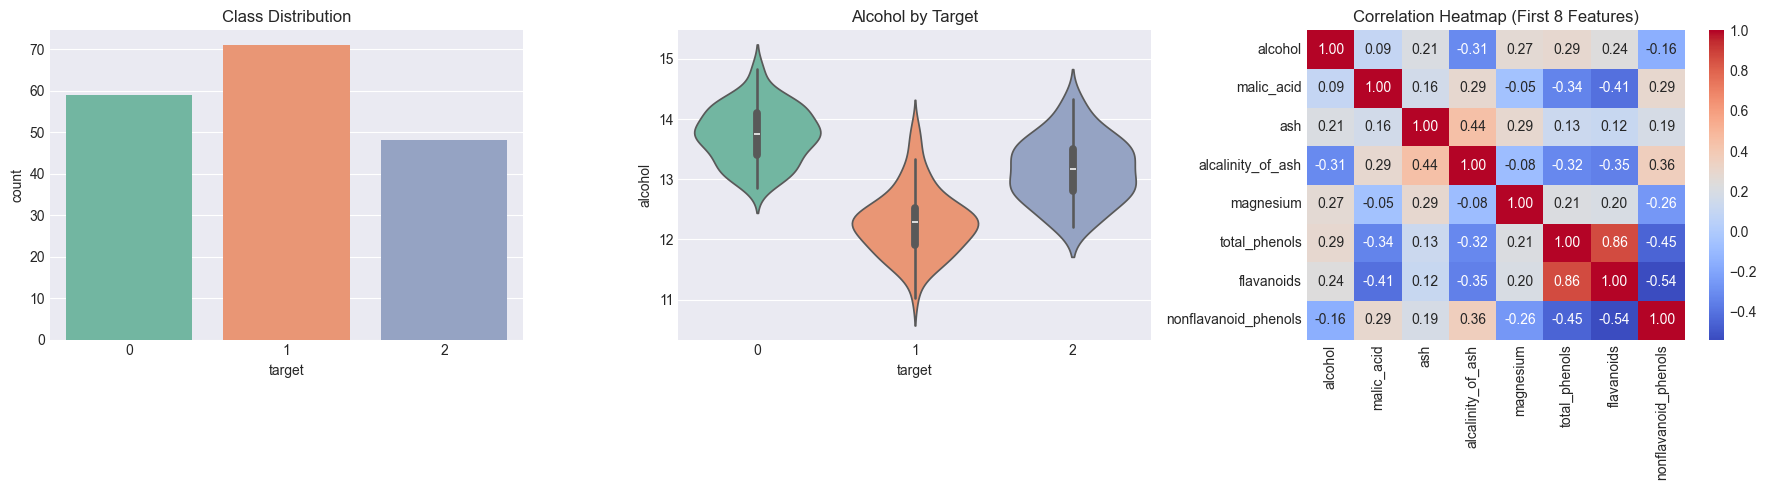

In [3]:
# ============================================================
# SECTION 5.3 — EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='target', palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution')

sns.violinplot(data=df, x='target', y='alcohol', palette='Set2', ax=axes[1])
axes[1].set_title('Alcohol by Target')

corr = df.iloc[:, :8].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlation Heatmap (First 8 Features)')

plt.tight_layout()
plt.show()


### 💡 SECTION 5.4 TIPS: Preprocessing
Random Forest does NOT require feature scaling (it is invariant to monotonic transformations). However, StandardScaler is shown here for completeness, as it won't hurt and keeps the pipeline consistent with other algorithms. Permutation importance on scaled data can be more reliable.


In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING
# ============================================================

X_full = df.drop(columns=['target'])
y_full = df['target']

X = X_full.copy()
y = y_full.copy()

# Note: will scale in modeling phase to prevent leakage.


## 6. Training the Model


In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT
# ============================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_temp_scaled = scaler.fit_transform(X_temp)


Train size: 106
Val size: 36
Test size: 36


### 💡 TIP: Key Random Forest Hyperparameters
- **n_estimators**: More trees = more stable, but diminishing returns after ~200-300
- **max_features**: 'sqrt' (default, $\sqrt{p}$) vs 'log2' vs None (all features). Lower = more diverse trees.
- **max_depth**: None by default (full depth). Limiting can reduce overfitting.
- **min_samples_leaf**: Higher = smoother decision boundary.
- **bootstrap**: True (bagging) vs False (use whole dataset per tree)
- **oob_score**: Free validation on out-of-bag samples
- **n_jobs=-1**: Use all CPU cores for parallel training


In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL
# ============================================================

rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

print(f"OOB Score: {rf.oob_score_:.4f}")
print(f"Train accuracy: {rf.score(X_train_scaled, y_train):.4f}")
print(f"Val accuracy: {rf.score(X_val_scaled, y_val):.4f}")

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
print(f"\nSingle DT Train accuracy: {dt.score(X_train_scaled, y_train):.4f}")
print(f"Single DT Val accuracy: {dt.score(X_val_scaled, y_val):.4f}")


OOB Score: 0.9717
Train accuracy: 1.0000
Val accuracy: 1.0000

Single DT Train accuracy: 1.0000
Single DT Val accuracy: 0.9167


## 7. Validation


CV Accuracy: 0.9791 ± 0.0277


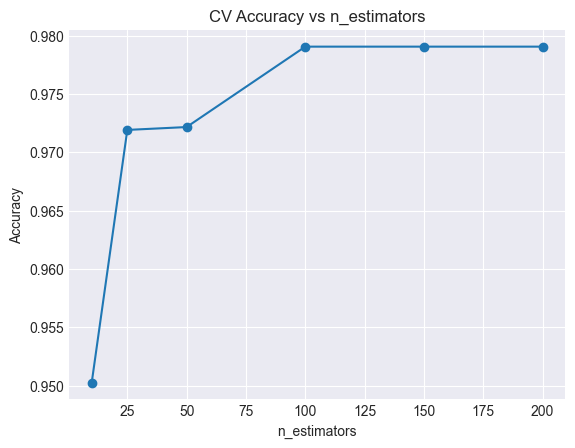

In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_temp_scaled, y_temp, cv=cv, scoring='accuracy')

print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

trees = [10, 25, 50, 100, 150, 200]
cv_means = []
for t in trees:
    model = RandomForestClassifier(n_estimators=t, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_temp_scaled, y_temp, cv=cv, scoring='accuracy')
    cv_means.append(scores.mean())

plt.plot(trees, cv_means, marker='o')
plt.title('CV Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.show()


In [8]:
# ============================================================
# SECTION 7.2 — VALIDATION SET METRICS
# ============================================================

y_val_pred = rf.predict(X_val_scaled)
y_val_prob = rf.predict_proba(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"ROC-AUC (OvR): {roc_auc_score(y_val, y_val_prob, multi_class='ovr'):.4f}")


Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC-AUC (OvR): 1.0000


### 🩺 Explaining Metrics for Wine Multiclass
Weighted averages for multiclass calculate metrics for each label, and find their average weighted by support (the number of true instances for each label). OvR for ROC-AUC computes the area under the ROC curve by considering one class as positive and all others as negative, averaged over all classes.


## 8. Testing


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



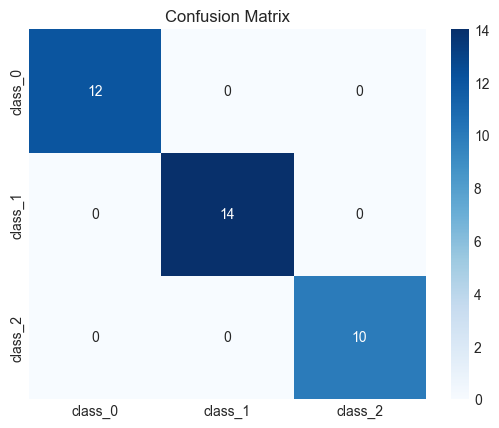

In [9]:
# ============================================================
# SECTION 8.1 & 8.2 — FINAL TEST EVAL & CONFUSION MATRIX
# ============================================================

y_test_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred, target_names=wine_data.target_names))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.title('Confusion Matrix')
plt.show()


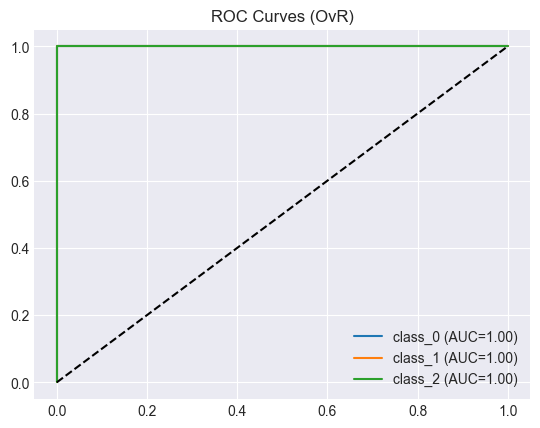

In [10]:
# ============================================================
# SECTION 8.3 — ROC CURVES (One-vs-Rest)
# ============================================================

y_test_prob = rf.predict_proba(X_test_scaled)

for i, class_name in enumerate(wine_data.target_names):
    y_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_test_prob[:, i])
    auc_score = roc_auc_score(y_binary, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (OvR)')
plt.legend()
plt.show()


## 9. Optimization & Hyperparameter Tuning


### 💡 TIP: Why RandomizedSearchCV for Random Forest
Random Forest has many hyperparameters. GridSearch with 4 params × 4 values each = 256 × 5 folds = 1280 model fits. RandomizedSearch samples only n_iter=50 random combinations — 50 × 5 = 250 fits but covers the space nearly as well. Much faster.


In [11]:
# ============================================================
# SECTION 9.1 — RANDOMIZEDSEARCHCV
# ============================================================

from scipy.stats import randint

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 15),
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
search.fit(X_temp_scaled, y_temp)


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': <scipy.stats....0024278425630>, ...}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV Score: {search.best_score_:.4f}")

best_rf = search.best_estimator_
y_opt_pred = best_rf.predict(X_test_scaled)
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_opt_pred, target_names=wine_data.target_names))


Best Parameters: {'bootstrap': True, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_split': 12, 'n_estimators': 500}
Best CV Score: 0.9862

Optimized Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 10. Feature Importance Analysis
MDI vs Permutation Importance. MDI can overestimate importance of high-cardinality features. Permutation importance is more reliable but slower.


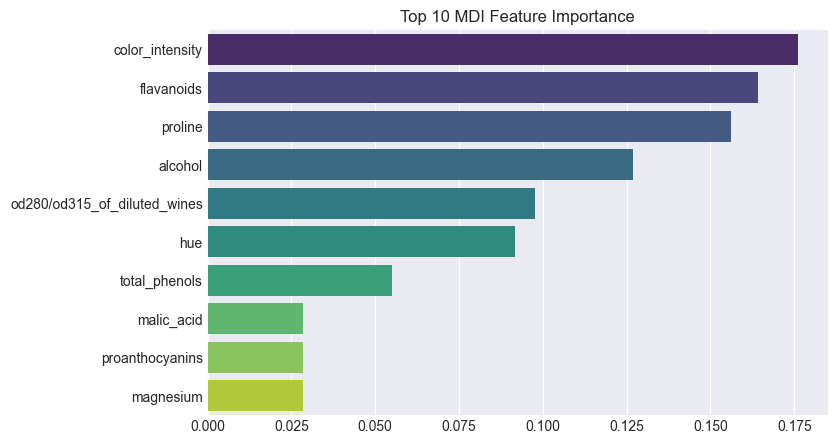

In [13]:
# ============================================================
# SECTION 10 — MDI FEATURE IMPORTANCE
# ============================================================

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = np.array(wine_data.feature_names)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices][:10], y=features[indices][:10], palette='viridis')
plt.title('Top 10 MDI Feature Importance')
plt.show()


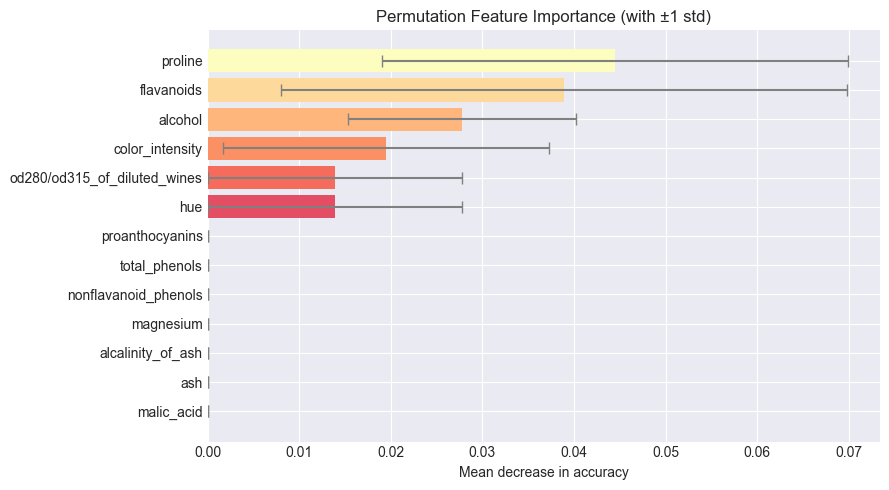

In [15]:
# ============================================================
# SECTION 10.2 — PERMUTATION IMPORTANCE
# ============================================================

result = permutation_importance(
    best_rf, X_test_scaled, y_test, n_repeats=10, random_state=42
)
perm_sorted_idx = result.importances_mean.argsort()[::-1]

means = result.importances_mean[perm_sorted_idx]
stds = result.importances_std[perm_sorted_idx]
labels = features[perm_sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.magma_r([i / len(labels) for i in range(len(labels))])
ax.barh(
    labels,
    means,
    xerr=stds,
    color=colors,
    align='center',
    error_kw=dict(ecolor='gray', capsize=4, elinewidth=1.5),
)
ax.set_xlabel('Mean decrease in accuracy')
ax.set_title('Permutation Feature Importance (with ±1 std)')
ax.invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()


## 11. Tips & Tricks Summary
1. **Don't Preoccupy with Scaling**: Tree algorithms are invariant to monotonic transformations.
2. **More Trees $\neq$ Overfitting**: Increasing `n_estimators` will never cause a Random Forest to overfit.
3. **Control Variance via Hyperparameters**: Decrease `max_depth`, or increase `min_samples_split` / `min_samples_leaf`.
4. **Leverage OOB Score**: If you are short on data, use the Out-of-Bag (`oob_score=True`) estimate as your validation score.
5. **Always Set `n_jobs=-1`**: Training random trees is entirely parallelizable.
6. **MDI vs Permutation**: Be cautious of MDI feature importances if features vary widely in their scale or cardinality.
7. **Handle Missing Values Externally**: Impute missing values prior to training in sklearn.
8. **Imbalance Handling**: Use `class_weight="balanced"`.
9. **Don't Forget Correlated Features**: RF will arbitrarily split feature importance among correlated variables.
10. **Extremely Randomized Trees (ExtraTrees)**: If Random Forest is still overfitting, try `ExtraTreesClassifier`.


## 12. Conclusion

Random Forest represents a massive leap forward from the single Decision Tree, successfully solving the tree's fundamental flaw: high variance and tendency to overfit. By injecting randomness into both the data subsampling and feature selection processes, it cultivates a diverse ensemble of trees that form a "wisdom of the crowd" consensus.

Due to its robustness, ease of use (requiring very little tuning), and lack of restrictive assumptions about data distribution or scale, Random Forest remains a foundational tool in any data scientist's toolkit. While more modern algorithms frequently surpass it in raw predictive power, Random Forest continues to serve as an indispensable, high-performing baseline for almost any tabular machine learning problem.
